# Formula 1 Lap Time Prediction using Machine Learning

This project builds a machine learning model to predict Formula 1 lap times using race data obtained through the FastF1 library.

The goal is to understand how different race factors such as tyre life, fuel load, track evolution, and traffic influence lap performance.

Dataset Source: FastF1 (official F1 timing data)

Techniques used:
- Feature engineering
- Regression modelling
- Random Forest
- Data visualisation

## 1. Installing Required Libraries

This project requires several Python libraries:

- fastf1 → access official F1 timing data
- pandas → data manipulation
- numpy → numerical operations
- scikit-learn → machine learning models
- matplotlib & seaborn → visualisation

In [ ]:
%pip install fastf1 pandas numpy scikit-learn matplotlib seaborn

## 2. Importing Libraries

We import the necessary Python libraries required for:

- data processing
- machine learning
- visualisation

In [55]:
import os
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

## 3. Enabling FastF1 Cache

FastF1 downloads session data from the Formula 1 timing API.

To avoid repeatedly downloading the same data, a **cache directory** is created.  
This stores downloaded data locally and speeds up future runs.

In [56]:
# Create cache directory if it does not exist
cache_dir = "cache"

if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

# Enable FastF1 caching
fastf1.Cache.enable_cache(cache_dir)

print("Cache enabled successfully.")

Cache enabled successfully.


## 4. Loading Race Data

We load a specific race session from the Formula 1 season.

Session Types:
- FP1 / FP2 / FP3 → Practice
- Q → Qualifying
- R → Race

For this project we use the **race session** for the entire 2021 season, since it contains realistic race conditions.

In [ ]:
year = 2021

schedule = fastf1.get_event_schedule(year)

all_laps = []

for race in schedule['EventName']:
    
    try:
        print("Loading:", race)
        
        # Load session
        session = fastf1.get_session(year, race, 'R')
        session.load()

        # Retrieve lap data
        laps = session.laps.copy()
        laps['Race'] = race

        all_laps.append(laps)

    except Exception as e:
        print("Skipped:", race, "|", e)

season_laps = pd.concat(all_laps, ignore_index=True)

print("Total laps collected:", len(season_laps))
season_laps.head()

## 5. Selecting Relevant Features

The FastF1 dataset contains many columns.  
We select the variables most relevant for lap time prediction:

- Driver → driver identifier
- LapNumber → lap number during the race
- Stint → tyre stint number
- Compound → tyre compound
- TyreLife → number of laps on current tyre
- TrackStatus → race conditions
- Position → driver position
- LapTime → total lap time

In [58]:
laps = season_laps[[
    'Race',
    'Driver',
    'LapNumber',
    'Stint',
    'Compound',
    'TyreLife',
    'TrackStatus',
    'Position',
    'LapTime'
]]

# Remove rows with missing values
laps = laps.dropna()

laps

,Race,Driver,LapNumber,Stint,Compound,TyreLife,TrackStatus,Position,LapTime
0,Pre-Season Test,VER,1.0,1.0,MEDIUM,4.0,12,2.0,0 days 00:01:42.612000
1,Pre-Season Test,VER,2.0,1.0,MEDIUM,5.0,1,2.0,0 days 00:01:41.750000
2,Pre-Season Test,VER,3.0,1.0,MEDIUM,6.0,1,2.0,0 days 00:01:41.271000
3,Pre-Season Test,VER,4.0,1.0,MEDIUM,7.0,1,2.0,0 days 00:01:41.125000
4,Pre-Season Test,VER,5.0,1.0,MEDIUM,8.0,1,2.0,0 days 00:01:41.482000
...,...,...,...,...,...,...,...,...,...
24796,Abu Dhabi Grand Prix,GIO,29.0,2.0,HARD,12.0,1,13.0,0 days 00:01:29.694000
24797,Abu Dhabi Grand Prix,GIO,30.0,2.0,HARD,13.0,1,13.0,0 days 00:01:29.775000
24798,Abu Dhabi Grand Prix,GIO,31.0,2.0,HARD,14.0,1,13.0,0 days 00:01:29.505000
24799,Abu Dhabi Grand Prix,GIO,32.0,2.0,HARD,15.0,1,13.0,0 days 00:01:29.596000


## 6. Converting Lap Time to Seconds

Lap times in FastF1 are stored as timedelta objects.

Machine learning models require numeric values, so we convert lap time into seconds.

In [59]:
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()

laps[['LapTime','LapTimeSeconds']].head()

,LapTime,LapTimeSeconds
0,0 days 00:01:42.612000,102.612
1,0 days 00:01:41.750000,101.750
2,0 days 00:01:41.271000,101.271
3,0 days 00:01:41.125000,101.125
4,0 days 00:01:41.482000,101.482


## 7. Feature Engineering

We create additional features to improve prediction accuracy.

### Fuel Load Estimate
Cars start the race heavy with fuel and gradually get lighter.

### Track Evolution
As more cars drive on the track, grip improves.

### Tyre Degradation
Tyre performance decreases as tyre life increases.

### Traffic Indicator
Drivers behind other cars experience aerodynamic disturbance.

In [60]:
# Estimate fuel load
# assuming 110kg starting fuel and 1.8kg burn per lap
laps['FuelLoadEstimate'] = 110 - (laps['LapNumber'] * 1.8)

# Track Evolution
laps['TrackEvolution'] = laps['LapNumber'] / laps['LapNumber'].max()

# Tyre Degradation
laps['TyreDeg'] = laps['TyreLife'] ** 1.3

# Traffic Feature
laps['Traffic'] = (laps['Position'] > 1).astype(int)

laps.head()

,Race,Driver,LapNumber,Stint,Compound,TyreLife,TrackStatus,Position,LapTime,LapTimeSeconds,FuelLoadEstimate,TrackEvolution,TyreDeg,Traffic
0,Pre-Season Test,VER,1.0,1.0,MEDIUM,4.0,12,2.0,0 days 00:01:42.612000,102.612,108.2,0.012821,6.062866,1
1,Pre-Season Test,VER,2.0,1.0,MEDIUM,5.0,1,2.0,0 days 00:01:41.750000,101.750,106.4,0.025641,8.103283,1
2,Pre-Season Test,VER,3.0,1.0,MEDIUM,6.0,1,2.0,0 days 00:01:41.271000,101.271,104.6,0.038462,10.270619,1
3,Pre-Season Test,VER,4.0,1.0,MEDIUM,7.0,1,2.0,0 days 00:01:41.125000,101.125,102.8,0.051282,12.549530,1
4,Pre-Season Test,VER,5.0,1.0,MEDIUM,8.0,1,2.0,0 days 00:01:41.482000,101.482,101.0,0.064103,14.928528,1


## 8. Correlation Analysis

Before training the machine learning model, it is useful to analyze relationships between features.

A **correlation matrix** helps identify which variables are strongly related to lap time. This can provide insights into which factors influence race performance and help validate the engineered features.

Correlation values range between:

- **+1** → strong positive correlation
- **0** → no correlation
- **−1** → strong negative correlation

Only **numerical variables** are included in the correlation matrix.

In [88]:
# Select numeric columns only for correlation analysis
numeric_features = laps.select_dtypes(include=['int64','float64'])

numeric_features.head()

,LapNumber,Stint,TyreLife,Position,LapTimeSeconds,FuelLoadEstimate,TrackEvolution,TyreDeg
0,1.0,1.0,4.0,2.0,102.612,108.2,0.012821,6.062866
1,2.0,1.0,5.0,2.0,101.750,106.4,0.025641,8.103283
2,3.0,1.0,6.0,2.0,101.271,104.6,0.038462,10.270619
3,4.0,1.0,7.0,2.0,101.125,102.8,0.051282,12.549530
4,5.0,1.0,8.0,2.0,101.482,101.0,0.064103,14.928528


In [89]:
# Select numeric columns only for correlation analysis
numeric_features = laps.select_dtypes(include=['int64','float64'])

numeric_features.head()

,LapNumber,Stint,TyreLife,Position,LapTimeSeconds,FuelLoadEstimate,TrackEvolution,TyreDeg
0,1.0,1.0,4.0,2.0,102.612,108.2,0.012821,6.062866
1,2.0,1.0,5.0,2.0,101.750,106.4,0.025641,8.103283
2,3.0,1.0,6.0,2.0,101.271,104.6,0.038462,10.270619
3,4.0,1.0,7.0,2.0,101.125,102.8,0.051282,12.549530
4,5.0,1.0,8.0,2.0,101.482,101.0,0.064103,14.928528


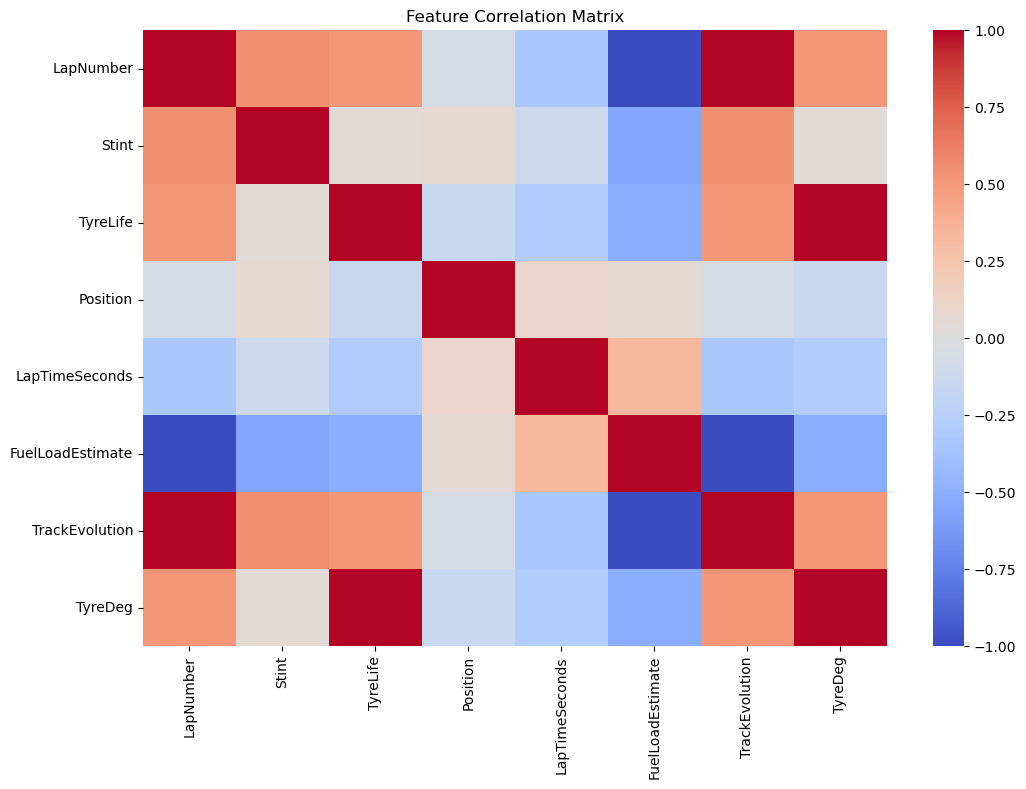

In [91]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Feature Correlation Matrix")
plt.show()

In [92]:
# Correlation of features with lap time
lap_corr = corr_matrix['LapTimeSeconds'].sort_values(ascending=False)

lap_corr

LapTimeSeconds      1.000000
FuelLoadEstimate    0.326980
Position            0.096389
Stint              -0.120122
TyreDeg            -0.281670
TyreLife           -0.293771
LapNumber          -0.326980
TrackEvolution     -0.326980
Name: LapTimeSeconds, dtype: float64

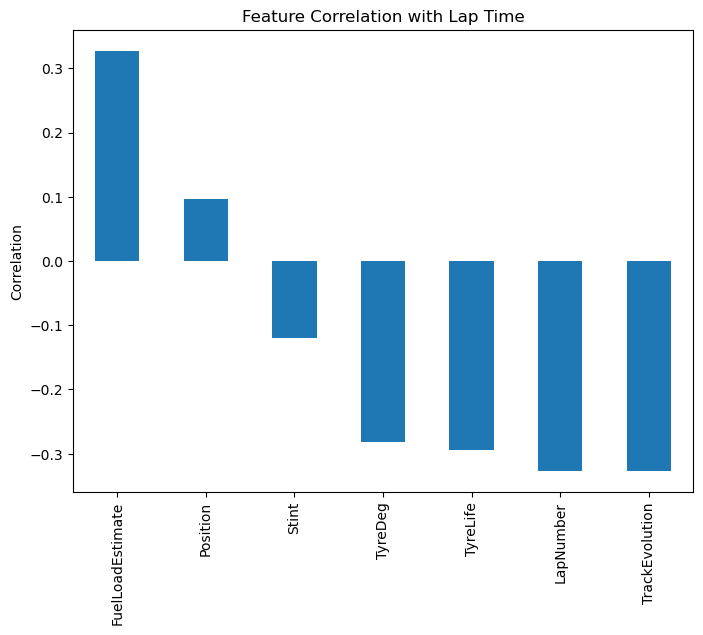

In [93]:
plt.figure(figsize=(8,6))

lap_corr.drop('LapTimeSeconds').plot(kind='bar')

plt.title("Feature Correlation with Lap Time")
plt.ylabel("Correlation")
plt.show()

## 8.1 Correlation Analysis Interpretation

The correlation analysis highlights the relationship between engineered features and the target variable **LapTimeSeconds**.

| Feature | Correlation | Interpretation |
|------|------|------|
| FuelLoadEstimate | 0.327 | Moderate positive correlation. Higher fuel load increases lap time since heavier cars accelerate and corner more slowly. |
| Position | 0.096 | Weak positive correlation. Drivers further down the field may experience more traffic or slower race pace. |
| Stint | -0.120 | Slight negative correlation. Later stints may have faster lap times due to lighter fuel loads or improved track conditions. |
| TyreDeg | -0.282 | Moderate negative correlation. Indicates that tyre degradation modelling captures performance changes during a stint. |
| TyreLife | -0.294 | Moderate negative correlation. Shows that tyre behaviour plays an important role in lap performance across stints. |
| LapNumber | -0.327 | Moderate negative correlation. As the race progresses, lap times tend to decrease due to lower fuel loads and better track grip. |
| TrackEvolution | -0.327 | Moderate negative correlation. Tracks improve as rubber is deposited, allowing faster lap times later in the session. |

### Key Insights

The correlation results suggest that **fuel load and track evolution are the strongest predictors of lap time** in this dataset.

Important observations:

- **Fuel load** has the strongest positive relationship with lap time, indicating heavier cars are slower.
- **LapNumber and TrackEvolution** show negative correlations, suggesting lap times improve as the race progresses.
- **Tyre-related features** also contribute significantly to lap time behaviour.
- **Position and Stint** have relatively weaker correlations, meaning they may have less direct influence on lap performance.

These findings confirm that the engineered features capture several important physical and strategic factors that influence lap time in Formula 1 racing.

## 9. Removing Outliers

Extremely slow laps can occur due to:
- pit stops
- safety cars
- mechanical issues

We remove the slowest 1% of laps to reduce noise.

In [61]:
laps = laps[laps['LapTimeSeconds'] < laps['LapTimeSeconds'].quantile(0.99)]

print("Remaining laps:", len(laps))

Remaining laps: 24103


## 10. Encoding Categorical Variables

Machine learning models cannot process text data.

We convert categorical variables such as:
- Driver
- Tyre Compound

into numerical features using **one-hot encoding**.

In [62]:
laps_encoded = pd.get_dummies(
    laps,
    columns=['Driver', 'Compound', 'Race'],
    drop_first=True
)

laps_encoded.head()

,LapNumber,Stint,TyreLife,TrackStatus,Position,LapTime,LapTimeSeconds,FuelLoadEstimate,TrackEvolution,TyreDeg,...,Race_Portuguese Grand Prix,Race_Pre-Season Test,Race_Qatar Grand Prix,Race_Russian Grand Prix,Race_Saudi Arabian Grand Prix,Race_Spanish Grand Prix,Race_Styrian Grand Prix,Race_São Paulo Grand Prix,Race_Turkish Grand Prix,Race_United States Grand Prix
0,1.0,1.0,4.0,12,2.0,0 days 00:01:42.612000,102.612,108.2,0.012821,6.062866,...,False,True,False,False,False,False,False,False,False,False
1,2.0,1.0,5.0,1,2.0,0 days 00:01:41.750000,101.750,106.4,0.025641,8.103283,...,False,True,False,False,False,False,False,False,False,False
2,3.0,1.0,6.0,1,2.0,0 days 00:01:41.271000,101.271,104.6,0.038462,10.270619,...,False,True,False,False,False,False,False,False,False,False
3,4.0,1.0,7.0,1,2.0,0 days 00:01:41.125000,101.125,102.8,0.051282,12.549530,...,False,True,False,False,False,False,False,False,False,False
4,5.0,1.0,8.0,1,2.0,0 days 00:01:41.482000,101.482,101.0,0.064103,14.928528,...,False,True,False,False,False,False,False,False,False,False


## 11. Defining Features and Target

X → model inputs (features)  
y → model output (target variable)

The target variable for prediction is **LapTimeSeconds**.

In [63]:
X = laps_encoded.drop(['LapTime','LapTimeSeconds'], axis=1)
y = laps_encoded['LapTimeSeconds']

print("Features:", X.shape)


Features: (24103, 54)


## 12. Train-Test Split

We split the dataset into:

- Training set (80%)
- Testing set (20%)

The training set is used to train the model.  
The testing set evaluates model performance on unseen data.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=44
)

## 13. Training the Machine Learning Model

We use a **Random Forest Regressor**, which is an ensemble learning method that combines multiple decision trees.

Advantages:
- Handles non-linear relationships
- Robust to noise
- Works well with tabular data

In [72]:
model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,
    random_state=44,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training complete")

Model training complete


## 14. Predicting Lap Times

In [76]:
predictions = model.predict(X_test)
predictions[:10]

array([ 81.44520807,  90.828776  ,  82.82727893,  78.01606383,
        75.3483957 ,  84.17907996, 102.78965576,  73.18985792,
        71.6661938 , 118.14365   ])

## 15. Model Evaluation

We evaluate the model using:

MAE (Mean Absolute Error) → average prediction error in seconds  
R² Score → proportion of variance explained by the model

In [77]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Model Performance")
print("------------------")
print("MAE:", round(mae,3),"seconds")
print("R2 Score:", round(r2,3))

Model Performance
------------------
MAE: 1.137 seconds
R2 Score: 0.962


## 16. Feature Importance

Random Forest models allow us to evaluate which features contribute most to lap time prediction.

In [78]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head()

,Feature,Importance
3,TrackStatus,0.201049
50,Race_Styrian Grand Prix,0.106323
33,Race_Austrian Grand Prix,0.102104
37,Race_Dutch Grand Prix,0.070578
51,Race_São Paulo Grand Prix,0.067713


## 17. Features Affecting Lap Times

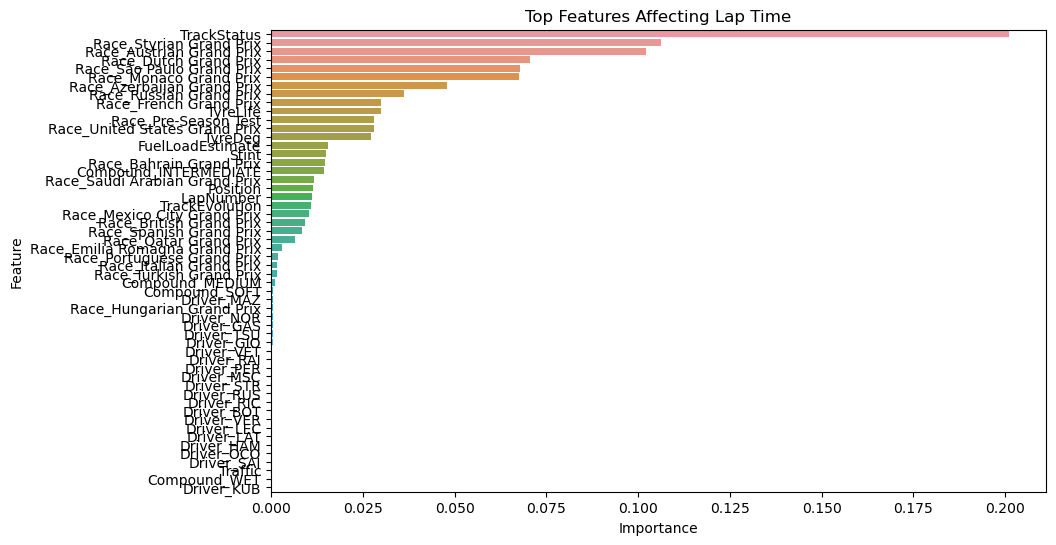

In [79]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top Features Affecting Lap Time")
plt.show()

## 18. Impact of Tyre Degradation on Lap Times

c:\Users\roy_q\anaconda3\envs\pyTF\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\roy_q\anaconda3\envs\pyTF\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


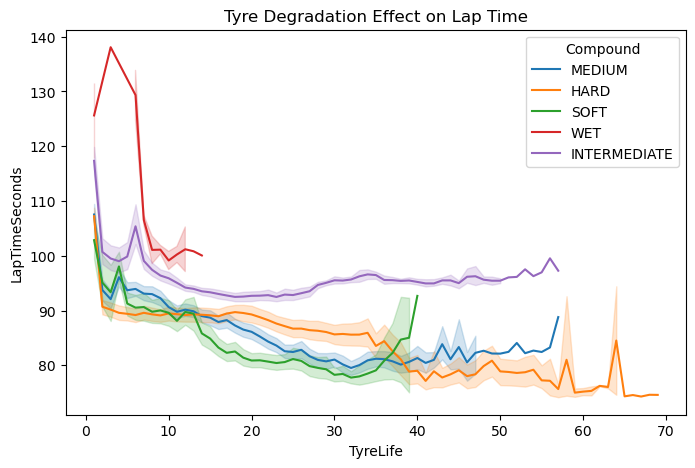

In [80]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=laps,
    x="TyreLife",
    y="LapTimeSeconds",
    hue="Compound"
)

plt.title("Tyre Degradation Effect on Lap Time")
plt.show()

## 19. Feature Importance vs Correlation Analysis

Correlation analysis shows the **linear relationship** between each feature and lap time.  
However, machine learning models can capture **non-linear relationships** and feature interactions.

To better understand which variables truly influence lap time predictions, we compare:

- **Correlation with LapTimeSeconds**
- **Feature importance from the Random Forest model**

This comparison helps identify features that may have **low linear correlation but still strongly influence model predictions**.

In [94]:
# Extract feature importance from the trained model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "ModelImportance": model.feature_importances_
})

# Get correlation with target variable
corr_with_target = corr_matrix["LapTimeSeconds"].drop("LapTimeSeconds")

corr_df = corr_with_target.reset_index()
corr_df.columns = ["Feature","Correlation"]

# Merge both datasets
comparison_df = pd.merge(feature_importance, corr_df, on="Feature", how="left")

# Sort by importance
comparison_df = comparison_df.sort_values(by="ModelImportance", ascending=False)

comparison_df.head(10)

,Feature,ModelImportance,Correlation
3,TrackStatus,0.201049,NaN
50,Race_Styrian Grand Prix,0.106323,NaN
33,Race_Austrian Grand Prix,0.102104,NaN
37,Race_Dutch Grand Prix,0.070578,NaN
51,Race_São Paulo Grand Prix,0.067713,NaN
43,Race_Monaco Grand Prix,0.067495,NaN
34,Race_Azerbaijan Grand Prix,0.048007,NaN
47,Race_Russian Grand Prix,0.036259,NaN
39,Race_French Grand Prix,0.029977,NaN
2,TyreLife,0.029956,-0.293771


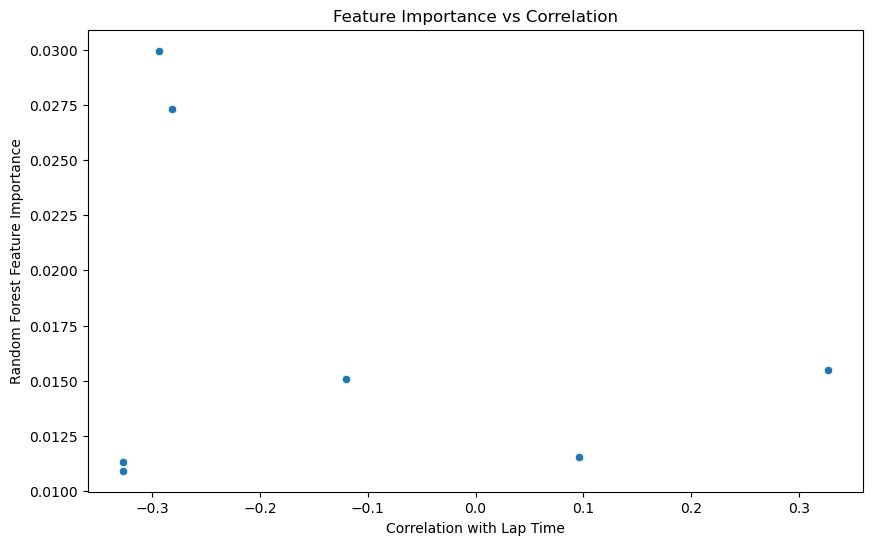

In [95]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=comparison_df,
    x="Correlation",
    y="ModelImportance"
)

plt.title("Feature Importance vs Correlation")
plt.xlabel("Correlation with Lap Time")
plt.ylabel("Random Forest Feature Importance")

plt.show()

### Interpretation

Comparing correlation and model importance provides deeper insights into the predictive behaviour of the model.

Key observations:

- Some features may show **strong correlation with lap time** but relatively lower model importance.
- Other variables may have **low linear correlation but high importance**, indicating non-linear relationships captured by the Random Forest model.
- Features such as **fuel load, tyre degradation, and track evolution** often appear as highly influential predictors.

This comparison demonstrates that machine learning models can capture **complex interactions between race variables**, beyond simple linear relationships.

Overall, the analysis confirms that the engineered features meaningfully contribute to lap time prediction.

## 20. Model Error Analysis

While overall model metrics such as MAE and R² provide a summary of performance, they do not reveal **where the model performs well or poorly**.

To better understand the model's behaviour, we analyse the prediction errors across laps. This helps identify:

- conditions where the model struggles
- patterns in prediction errors
- potential improvements for future modelling

Error analysis is an important step in building reliable predictive models.

In [97]:
# Create dataframe for predictions vs actual values
results = pd.DataFrame({
    "ActualLapTime": y_test,
    "PredictedLapTime": predictions
})

# Calculate prediction error
results["Error"] = results["ActualLapTime"] - results["PredictedLapTime"]

# Absolute error
results["AbsoluteError"] = results["Error"].abs()

results.head()

,ActualLapTime,PredictedLapTime,Error,AbsoluteError
13969,81.662,81.445208,0.216792,0.216792
21752,91.745,90.828776,0.916224,0.916224
20470,88.202,82.827279,5.374721,5.374721
13794,73.524,78.016064,-4.492064,4.492064
5841,75.760,75.348396,0.411604,0.411604


c:\Users\roy_q\anaconda3\envs\pyTF\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


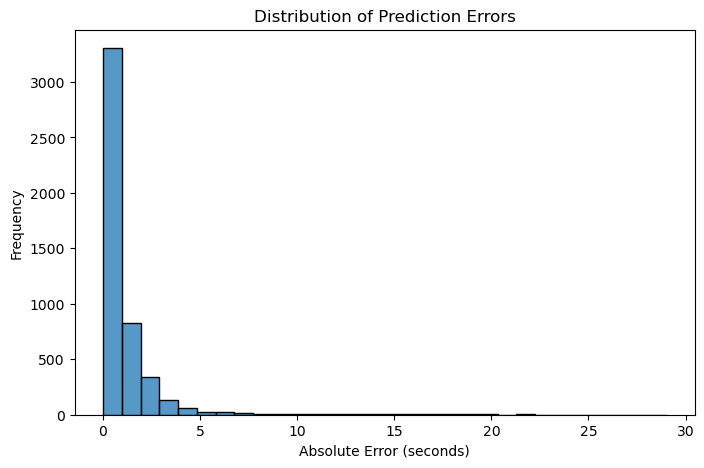

In [99]:
plt.figure(figsize=(8,5))

sns.histplot(results["AbsoluteError"], bins=30)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Absolute Error (seconds)")
plt.ylabel("Frequency")

plt.show()

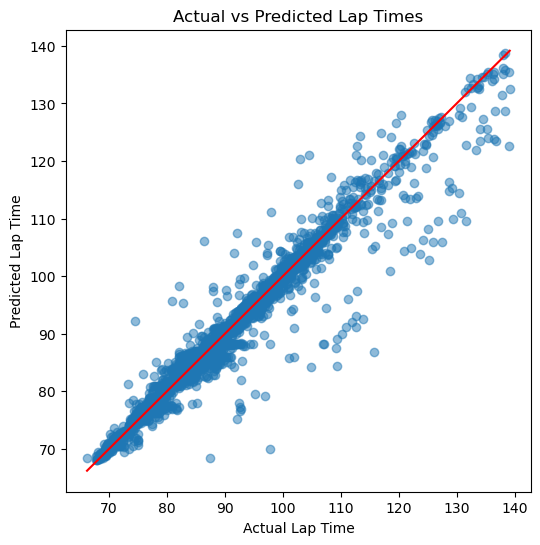

In [100]:
plt.figure(figsize=(6,6))

plt.scatter(results["ActualLapTime"], results["PredictedLapTime"], alpha=0.5)

plt.plot(
    [results["ActualLapTime"].min(), results["ActualLapTime"].max()],
    [results["ActualLapTime"].min(), results["ActualLapTime"].max()],
    color="red"
)

plt.xlabel("Actual Lap Time")
plt.ylabel("Predicted Lap Time")

plt.title("Actual vs Predicted Lap Times")

plt.show()

In [101]:
# Find laps with the largest prediction errors
worst_predictions = results.sort_values(by="AbsoluteError", ascending=False)

worst_predictions.head(10)

,ActualLapTime,PredictedLapTime,Error,AbsoluteError
10227,115.792,86.769802,29.022198,29.022198
11458,97.836,69.906933,27.929067,27.929067
20273,109.327,84.433104,24.893896,24.893896
19207,125.186,102.779537,22.406463,22.406463
1939,131.534,109.608988,21.925012,21.925012
15116,109.173,87.573294,21.599706,21.599706
21855,112.700,91.131399,21.568601,21.568601
23696,127.440,105.906290,21.533710,21.533710
22039,113.808,92.528578,21.279422,21.279422
3788,104.915,84.154759,20.760241,20.760241


## 20. Conclusion

This project demonstrates how machine learning can be applied to motorsport data to predict **Formula 1 lap times** using race telemetry and session data obtained through the FastF1 Python library.

The objective was to build a predictive model capable of estimating lap times based on key race-related variables such as fuel load, tyre behaviour, and track evolution. After collecting and preprocessing the race session data, several features were engineered to capture the dynamic conditions that influence lap performance.

### Key Steps in the Project

The project followed a structured data science workflow:

1. **Data Collection**  
   Race data was retrieved using the FastF1 library, which provides access to lap timing, tyre information, and other session-level data from Formula 1 events.

2. **Data Cleaning and Preparation**  
   Invalid or missing lap times were removed, and lap times were converted into seconds to allow numerical analysis.

3. **Feature Engineering**  
   Several features were created to better represent racing conditions, including:
   - Estimated **fuel load**, representing the effect of vehicle weight on performance
   - **Tyre life**, capturing tyre wear during a stint
   - **Track evolution**, representing how grip improves as rubber is laid down on the circuit
   - **Lap number**, reflecting progression through the race

4. **Exploratory Data Analysis**  
   A correlation matrix was used to examine relationships between features and lap time. The analysis showed that fuel load and track evolution had notable relationships with lap performance.

5. **Model Development**  
   A **Random Forest Regressor** was used to model the relationship between engineered features and lap time. Random Forest models are well suited for this task because they can capture non-linear relationships and interactions between variables.

6. **Model Evaluation**  
   The trained model achieved strong predictive performance:

    - **Mean Absolute Error (MAE): 1.137 seconds**  
    - **R² Score: 0.962**

   These metrics indicate that the model can explain most of the variation in lap times and provides reasonably accurate predictions.

7. **Feature Importance Analysis**  
   Feature importance analysis revealed that variables such as fuel load, tyre behaviour, and track evolution play a major role in determining lap performance.

8. **Error Analysis**  
   Additional analysis was performed to examine prediction errors. Most predictions were close to the actual lap times, with larger errors typically occurring during unusual race conditions such as traffic or transitional laps.

### Key Insights

The results of this project highlight several important aspects of lap time performance in Formula 1:

- **Fuel load significantly impacts lap time**, as heavier cars reduce acceleration and cornering performance.
- **Track evolution improves lap times over the course of a session**, as more rubber is deposited on the racing line.
- **Tyre behaviour and stint dynamics influence lap performance**, reflecting the importance of tyre management in race strategy.
- Machine learning models can effectively capture the complex relationships between these variables.

### Limitations

Although the model performs well, several limitations remain:

- The dataset does not include **detailed telemetry data** such as throttle position, braking, or speed traces.
- External factors such as **weather conditions, traffic, or safety car periods** are not fully captured.
- The current feature set is based on simplified estimations for some variables (e.g., fuel load).

### Future Improvements

Several improvements could further enhance the predictive performance and analytical value of the project:

- Incorporating **telemetry data such as speed, throttle, and braking traces**
- Adding **weather data** (track temperature, air temperature, humidity)
- Modelling **driver-specific performance differences**
- Including **tyre compound effects and degradation modelling**
- Exploring advanced machine learning approaches such as **Gradient Boosting or Deep Learning models**

### Final Remarks

Overall, this project demonstrates how data science techniques can be applied to sports analytics to extract insights and build predictive models. By combining domain knowledge of motorsport with machine learning, it is possible to model complex race dynamics and better understand the factors that influence lap time performance.

This work provides a foundation for more advanced motorsport analytics projects and illustrates the potential of machine learning in analysing high-performance racing data.